                                     **Factor Regressions**

Rt - Rf,t = a + b1(mkt-Rf) + B2(SMB)t + B3(HML)t + B4(RMW)t + B5(CMA)t + B6(MOM)t + et

Rt - Rf,t = Excess retun. The stock's return minus the risk free rate (usually US Treasury bill rate). This is what the Factor Regression model is tryinng to explain.

a (alpha) = The unexplained return. If this is positive and statistically signficant it means the stock is generating returns that can't be explained by any of the 6 factors - geniun skill or edge.

b1 (Mkt - Rf) = Market Factor - How sensitive the stock is to overall market movements. A beta of 1.2 means the stock moves 1.2x the market. This is the original CAPM factor.

b2(SMB) = Small Minus Big -  The size factor. Small cap stocks historically outperform large cap stocks. SMB captures how much of your return comes from exposure to small cap risk.

B3 (HML) — High Minus Low — The value factor. High book-to-market (value) stocks historically outperform low book-to-market (growth) stocks. Captures value vs growth exposure.

B4 (RMW) — Robust Minus Weak — The profitability factor. Companies with robust operating profitability outperform those with weak profitability. Added in Fama-French 5 factor model.

B5 (CMA) — Conservative Minus Aggressive — The investment factor. Companies that invest conservatively outperform those that invest aggressively. Also added in the 5 factor model.

B6 (MOM) — Momentum — The momentum factor. Stocks that have performed well recently continue to outperform. This is the factor your pipeline is currently computing.

et — Error term. The portion of return not explained by any factor.


In [1]:
# Install Packages
%pip install numpy
%pip install pandas
%pip install yfinance
%pip install statsmodels
%pip install getFamaFrenchFactors
%pip install lxml
%pip install openbb as obb

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached getFamaFrenchFactors-0.0.5-py3-none-any.whl.metadata (1.2 kB)
  Using cached bs4-0.0.2-py2.py3-none-any.whl.metadata (411 bytes)
Using cached getFamaFrenchFactors-0.0.5-py3-none-any.whl (4.6 kB)
Using cached bs4-0.0.2-py2.py3-none-any.whl (1.2 kB)

   ---------------------------------------- 2/2 [getFamaFrenchFactors]

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as


In [3]:
# Import Packages
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import lxml
import getFamaFrenchFactors as gff
from openbb import obb
obb.user.preferences.output_type = "dataframe"


In [20]:
# Get Data
symbols = ['VTI', 'AVUV']

data = obb.equity.price.historical(
    symbols,
    start_date = '1990-01-01',
    provider='yfinance',
    auto_adjust = True,
    interval = '1M'
).pivot(columns="symbol", values="close")
data


symbol,AVUV,VTI
date,,
2001-06-01,NaN,56.500000
2001-07-01,NaN,55.419998
2001-08-01,NaN,52.174999
2001-09-01,NaN,47.474998
2001-10-01,NaN,48.450001
...,...,...
2025-12-01,101.980003,335.269989
2026-01-01,109.269997,340.570007
2026-02-01,112.980003,338.769989


In [ ]:
# Clean up Data output
data.index = pd.to_datetime(data.index)
data = data.to_period('M')

In [ ]:
rets = data.pct_change()

symbol,AVUV,VTI
date,,
2001-06,NaN,NaN
2001-07,NaN,-0.019115
2001-08,NaN,-0.058553
2001-09,NaN,-0.090081
2001-10,NaN,0.020537
...,...,...
2025-12,0.008405,-0.003092
2026-01,0.071485,0.015808
2026-02,0.033953,-0.005285


In [ ]:
rets = rets.dropna()

symbol,AVUV,VTI
date,,
2019-10,0.021253,0.021060
2019-11,0.024074,0.037878
2019-12,0.035338,0.022497
2020-01,-0.087523,-0.000611
2020-02,-0.112722,-0.079990
...,...,...
2025-12,0.008405,-0.003092
2026-01,0.071485,0.015808
2026-02,0.033953,-0.005285


<Axes: xlabel='date'>

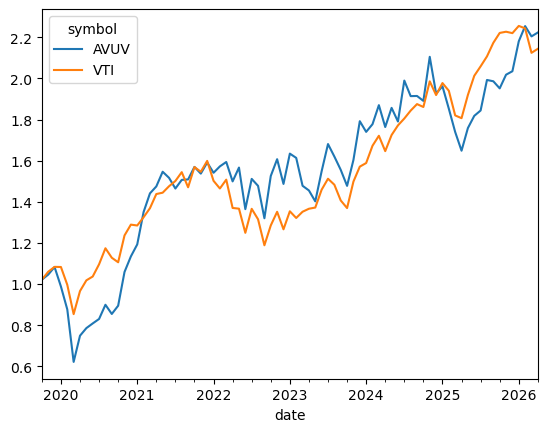

In [ ]:
# Plot Compuond Returns
(1+rets).cumprod().plot()

In [41]:
# Get Fama French 5 factor model
ff_5_factor_model = gff.famaFrench5Factor().set_index('date_ff_factors').to_period('M')
ff_momentum_factor = gff.momentumFactor().set_index('date_ff_factors').to_period('M')

In [42]:
# Look at Fama 5 Data
ff_5_factor_model

,Mkt-RF,SMB,HML,RMW,CMA,RF
date_ff_factors,,,,,,
1963-07,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027
1963-08,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025
1963-09,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027
1963-10,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029
1963-11,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027
...,...,...,...,...,...,...
2025-10,0.0196,-0.0131,-0.0310,-0.0524,-0.0403,0.0037
2025-11,-0.0013,0.0147,0.0376,0.0144,0.0068,0.0030
2025-12,-0.0036,-0.0022,0.0242,0.0040,0.0037,0.0034


In [43]:
# Look at Momentum Factor Data
ff_momentum_factor

,MOM
date_ff_factors,
1927-01,0.0057
1927-02,-0.0150
1927-03,0.0352
1927-04,0.0436
1927-05,0.0278
...,...
2025-10,0.0027
2025-11,-0.0180
2025-12,-0.0241


<Axes: xlabel='date_ff_factors'>

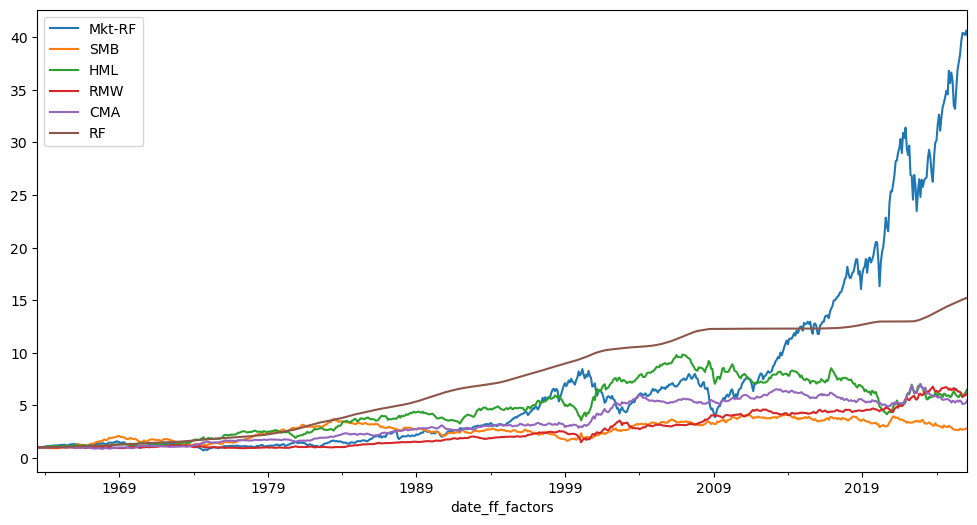

In [40]:
(1+ff_5_factor_model).cumprod().plot(figsize=(12, 6))

<Axes: xlabel='date_ff_factors'>

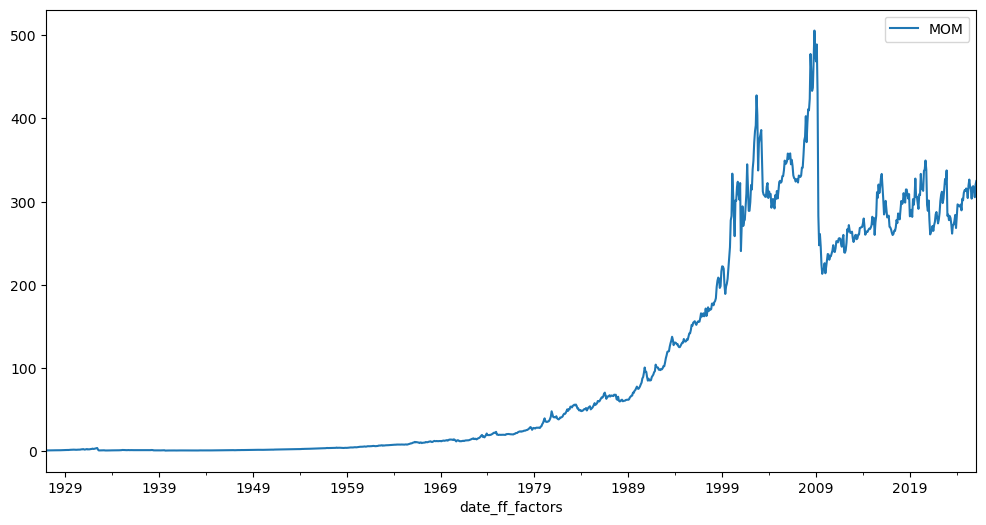

In [44]:
(1+ ff_momentum_factor).cumprod().plot(figsize=(12,6))

In [45]:
# Join Fama 5 French and Momentum Factor
ff_6_factor_model = ff_5_factor_model.join(ff_momentum_factor)

In [46]:
# look at data for new 6 factor model
ff_6_factor_model

,Mkt-RF,SMB,HML,RMW,CMA,RF,MOM
date_ff_factors,,,,,,,
1963-07,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,0.0101
1963-08,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,0.0100
1963-09,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,0.0012
1963-10,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,0.0313
1963-11,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,-0.0078
...,...,...,...,...,...,...,...
2025-10,0.0196,-0.0131,-0.0310,-0.0524,-0.0403,0.0037,0.0027
2025-11,-0.0013,0.0147,0.0376,0.0144,0.0068,0.0030,-0.0180
2025-12,-0.0036,-0.0022,0.0242,0.0040,0.0037,0.0034,-0.0241


<Axes: xlabel='date_ff_factors'>

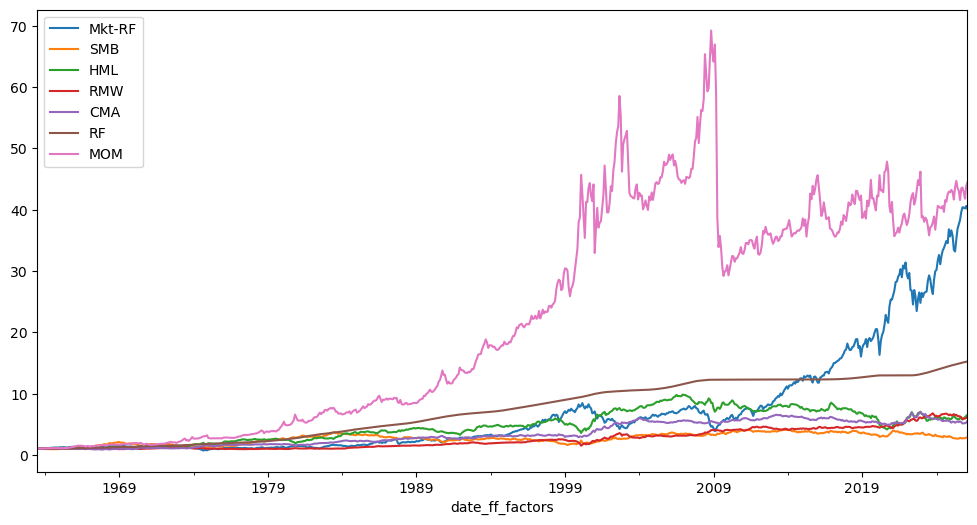

In [47]:
# Graph cumulative returns of the 6 factors
(1+ff_6_factor_model).cumprod().plot(figsize=(12,6))

In [ ]:
# Clean up ff_6_factor_model
ff_6_factor_model = ff_6_factor_model[[*ff_6_factor_model.columns.drop('RF'), 'RF']] ## RF last column
ff_6_factor_model 

,Mkt-RF,SMB,HML,RMW,CMA,MOM,RF
date_ff_factors,,,,,,,
1963-07,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0101,0.0027
1963-08,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0100,0.0025
1963-09,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0012,0.0027
1963-10,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0313,0.0029
1963-11,-0.0086,-0.0085,0.0173,-0.0043,0.0227,-0.0078,0.0027
...,...,...,...,...,...,...,...
2025-10,0.0196,-0.0131,-0.0310,-0.0524,-0.0403,0.0027,0.0037
2025-11,-0.0013,0.0147,0.0376,0.0144,0.0068,-0.0180,0.0030
2025-12,-0.0036,-0.0022,0.0242,0.0040,0.0037,-0.0241,0.0034


In [ ]:
def factor_regression(rets, factor_model):
    # common index
    common_idx = rets.index.intersection(factor_model.index)
    rets = rets.loc[common_idx]
    factor_model = factor_model.loc[common_idx]

    #prep data for regression 
    rets_excess = rets - factor_model[['RF']].values
    factor_model_minus_RF = factor_model[[*ff_6_factor_model.columns.drop('RF')]]
    factor_model_minus_RF['Alpha'] = 1

    # run regression
    lm = sm.OLS(rets_excess, factor_model_minus_RF).fit()
    factor_loadings = lm.params
    factor_loadings.columns = rets.columns

    # Calculate annualized alpha
    alpha_per_period = factor_loadings.loc[['Alpha']]
    annualized_alpha = ((1+alpha_per_period)**12)-1
    annualized_alpha.index = ['Annualized Alpha']
    factor_loadings = pd.concat([factor_loadings, annualized_alpha])

    # Alpha & annualized alpha in %
    factor_loadings = factor_loadings.round(2)
    factor_loadings = factor_loadings.astype(object)
    factor_loadings.loc[['Alpha']] = (alpha_per_period * 100).round(2).astype(str) + '%'
    factor_loadings.loc[['Annualized Alpha']] = (annualized_alpha * 100).round(2).astype(str) + '%'
    return factor_loadings




In [72]:
factor_regression(rets, ff_6_factor_model)

symbol,AVUV,VTI
Mkt-RF,1.07,1.0
SMB,0.91,-0.0
HML,0.55,0.04
RMW,0.29,0.03
CMA,-0.07,-0.03
MOM,0.01,0.01
Alpha,-0.1%,-0.17%
Annualized Alpha,-1.15%,-2.01%


In [77]:
def adjR_squared(symbol, rets, factor_model):
    ticker_rets = rets[[symbol]].copy()
    common_idx = ticker_rets.index.intersection(factor_model.index)
    ticker_rets = ticker_rets.loc[common_idx]
    factor_model = factor_model.loc[common_idx]

    #prep data for regression 
    rets_excess = ticker_rets - factor_model[['RF']].values
    factor_model_minus_RF = factor_model[[*ff_6_factor_model.columns.drop('RF')]]
    factor_model_minus_RF['Alpha'] = 1

    # Regression
    lm = sm.OLS(rets_excess, factor_model_minus_RF).fit()
    factor_loadings = lm.rsquared_adj

    return(factor_loadings)


In [ ]:
# Adjusted R_Squared of AVUV using the fama french 6 factor model to predict excess returns
adjR_squared('AVUV', rets, ff_6_factor_model)

np.float64(0.9740123894126549)

In [ ]:
# Adjusted R_Squared of VTI using the fama french 6 factor model to predict excess returns
adjR_squared('VTI', rets, ff_6_factor_model)

np.float64(0.9978459148862626)

**Rolling Factor Regression**


In [84]:
def rolling_factor_regression(rets, factor_model, roll_window=36):
    # common index
    common_idx = rets.index.intersection(factor_model.index)
    rets = rets.loc[common_idx]
    factor_model = factor_model.loc[common_idx]

    #prep data for regression 
    rets_excess = rets - factor_model[['RF']].values
    factor_model_minus_RF = factor_model[[*ff_6_factor_model.columns.drop('RF')]]

    # rolling window
    n_periods = rets.shape[0]
    windows = [(start, start+roll_window) for start in range (n_periods - roll_window + 1)]

    if n_periods <= roll_window:
        print("Sample smaller than roll window.")
        return

    # Rolling Regression
    results = {}
    for ret_excess in rets_excess:
        factor_loadings_per_window = []
        for win in windows:
            lm = sm.OLS(rets_excess[ret_excess].iloc[win[0]:win[1]], factor_model_minus_RF.iloc[win[0]:win[1]]).fit()
            factor_loadings = lm.params
            factor_loadings['date'] = rets_excess.index[win[1] - 1]
            factor_loadings_per_window.append(factor_loadings)
        results[ret_excess] = pd.DataFrame(factor_loadings_per_window).set_index('date')
    
    return results


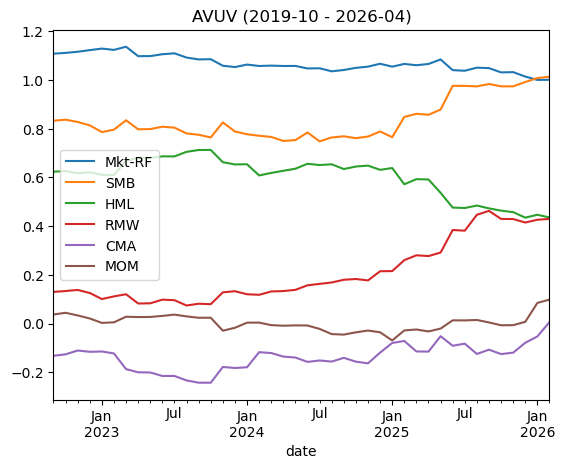

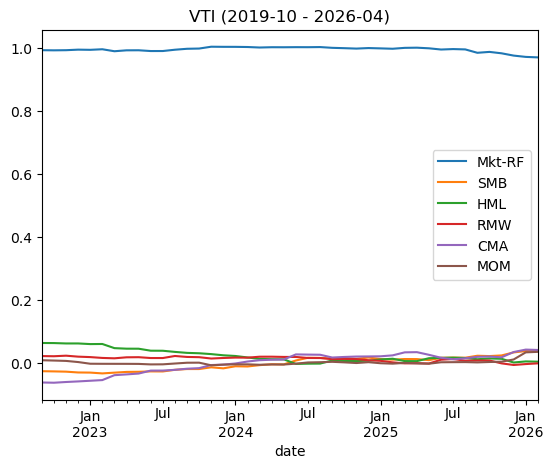

In [96]:
results = rolling_factor_regression(rets, ff_6_factor_model)

for ticker in results:
    results[ticker].plot(title = f"{ticker} ({rets.index[0]} - {rets.index[-1]})")

